In [57]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.data_utils import preprocess_features
from models.rnn_models import *
from models.transformer import *
from models.tcn import *


In [27]:
df_raw = pd.read_csv("data/Project1140.csv")
df_raw["Datetime"] = pd.to_datetime(df_raw["date"])


Hist feats: ['Capacity_Factor_hist', 'month_cos', 'month_sin', 'hour_cos', 'hour_sin', 'daypos_cos', 'daypos_sin', 'hourpos_sin', 'hourpos_cos']
Fcst feats: []
Rows: 144145
hist_dim = 9
fcst_dim = 0
{'model': 'Trasnformer', 'model_complexity': 'low', 'use_pv': True, 'use_hist_weather': False, 'use_forecast': False, 'use_ideal_nwp': False, 'use_time_encoding': True, 'weather_category': 'all_weather', 'past_hours': 24, 'future_hours': 24, 'start_date': '2022-01-01', 'end_date': '2024-09-28', 'd_model': 32, 'hidden_dim': 16, 'num_heads': 2, 'num_layers': 1, 'dropout': 0.1, 'tcn_channels': [16, 32], 'kernel_size': 3, 'batch_size': 64, 'learning_rate': 0.001, 'te_dim': 8}


In [69]:
model_path = "/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/pt/LSTM/best_model_LSTM_low_PV_24h_TE.pt"

model = Transformer(hist_dim, fcst_dim, config)


state = torch.load(model_path, map_location="cpu")
model.load_state_dict(state)
model.eval()

print("Model loaded successfully.")


RuntimeError: Error(s) in loading state_dict for Transformer:
	Missing key(s) in state_dict: "hist_proj.weight", "hist_proj.bias", "encoder.layers.0.self_attn.in_proj_weight", "encoder.layers.0.self_attn.in_proj_bias", "encoder.layers.0.self_attn.out_proj.weight", "encoder.layers.0.self_attn.out_proj.bias", "encoder.layers.0.linear1.weight", "encoder.layers.0.linear1.bias", "encoder.layers.0.linear2.weight", "encoder.layers.0.linear2.bias", "encoder.layers.0.norm1.weight", "encoder.layers.0.norm1.bias", "encoder.layers.0.norm2.weight", "encoder.layers.0.norm2.bias", "head.0.weight", "head.0.bias", "head.3.weight", "head.3.bias". 
	Unexpected key(s) in state_dict: "model_state_dict". 

In [35]:
# ===========================================
# 1. Determine model input dimensions
# ===========================================

# Use the hist_feats and fcst_feats from preprocessing
hist_dim = len(hist_feats)
fcst_dim = len(fcst_feats) if fcst_feats else 0

print("Histogram feature dim:", hist_dim)
print("Forecast feature dim:", fcst_dim)

# ===========================================
# 2. Rebuild model config EXACTLY as training
# ===========================================
mp = config["model_params"].copy()

mp["hidden_dim"]        = config["model_params"]["hidden_dim"]
mp["num_layers"]        = config["model_params"]["num_layers"]
mp["dropout"]           = config["model_params"]["dropout"]
mp["use_forecast"]      = config.get("use_forecast", False)
mp["use_time_encoding"] = config.get("use_time_encoding", True)

mp["future_hours"]      = config["future_hours"]   # 24
mp["past_hours"]        = config["past_hours"]     # 24
mp["te_dim"]            = config["model_params"].get("te_dim", 8)

print("\nModel Parameters:")
for k, v in mp.items():
    print(f"  {k}: {v}")

# ===========================================
# 3. Instantiate model and load weights
# ===========================================
model = LSTM(hist_dim, fcst_dim, mp)

state = torch.load("/Users/jacobfernandez/Desktop/Research/FA2025/SolarPrediction/one_setup_results/LSTM.pt", map_location="cpu")
model.load_state_dict(state)
model.eval()

print("\nModel loaded and ready for sliding inference.")


Histogram feature dim: 9
Forecast feature dim: 0

Model Parameters:
  hidden_dim: 16
  num_layers: 1
  dropout: 0.1
  d_model: 32
  te_dim: 8
  use_forecast: False
  use_time_encoding: True
  future_hours: 24
  past_hours: 24

Model loaded and ready for sliding inference.


In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def sliding_48h_forecast(
    model,
    df_clean,
    hist_feats,
    fcst_feats,
    scaler_target,
    config,
    start_idx=0  # index of first sliding forecast
):
    """
    Generates a 48-hour visualization consisting of:
      • GT from t=0 → t=48h (288 points @ 10-min = 48*6)
      • 24 forecast curves (each 24h long, starting at hour offsets 0..23)

    model          → trained PyTorch model (already .eval())
    df_clean       → preprocessed DF from preprocess_features()
    hist_feats     → same list as during training
    fcst_feats     → same list as during training
    scaler_target  → target scaler
    config         → full config dict (past_hours, future_hours, etc.)
    start_idx      → sample index to slide over

    NOTE: past_hours = 24h → 144 steps
          future_hours = 24h → 144 steps
          48h window = 288 steps
    """

    model.eval()

    past_steps   = config["past_hours"] * 6
    future_steps = config["future_hours"] * 6
    
    # The sliding window will need GT for 48 hours:
    total_required_steps = past_steps + future_steps + (23 * 6)  # sliding start offsets

    # Ensure dataset is long enough
    assert len(df_clean) > start_idx + total_required_steps, \
        "Not enough data to perform sliding inference."

    # ------------------------------------------
    # Extract 48-hour ground truth (288 points)
    # ------------------------------------------
    gt_start = start_idx + past_steps
    gt_end   = gt_start + 48 * 6   # 48h horizon

    gt_48h_scaled = df_clean.iloc[gt_start:gt_end]["Capacity Factor"].values.reshape(-1, 1)
    gt_48h = scaler_target.inverse_transform(gt_48h_scaled).flatten()

    plt.figure(figsize=(18, 9))
    plt.plot(gt_48h, label="Ground Truth (48h)", linewidth=3, color="black")

    # ------------------------------------------
    # LOOP: Generate 24 predictions
    # ------------------------------------------
    for offset in range(0, 24):  # 0..23 hours
        step_shift = offset * 6  # convert hours→10min steps

        # Index where THIS forecast starts
        i = start_idx + past_steps + step_shift

        # Build historical window
        hist_data = df_clean.iloc[i - past_steps : i]
        Xh = hist_data[hist_feats].values.astype(np.float32).reshape(1, past_steps, -1)

        # Build future forecast inputs (if model uses forecast weather)
        if len(fcst_feats) > 0:
            fcst_data = df_clean.iloc[i : i + future_steps]
            Xf = fcst_data[fcst_feats].values.astype(np.float32).reshape(1, future_steps, -1)
        else:
            Xf = None

        # PyTorch tensors
        xh_t = torch.tensor(Xh, dtype=torch.float32)
        xf_t = torch.tensor(Xf, dtype=torch.float32) if Xf is not None else None

        # Model prediction
        with torch.no_grad():
            if xf_t is not None:
                pred_scaled = model(xh_t, xf_t).numpy().reshape(-1, 1)
            else:
                pred_scaled = model(xh_t).numpy().reshape(-1, 1)

        # Unscale
        pred = scaler_target.inverse_transform(pred_scaled).flatten()

        # RMSE over THIS forecast range
        gt_slice = gt_48h[step_shift : step_shift + future_steps]
        rmse = np.sqrt(np.mean((pred - gt_slice) ** 2))

        # Plot shifted into the 48h window
        t0 = step_shift
        t1 = step_shift + future_steps
        plt.plot(
            np.arange(t0, t1),
            pred,
            alpha=0.4,
            linewidth=2,
            label=f"+{offset}h Forecast (RMSE={rmse:.2f})"
        )

    plt.title("Sliding 24h Forecasts Over 48 Hours")
    plt.xlabel("Time Steps (10-min intervals, 288 = 48h)")
    plt.ylabel("Capacity Factor (%)")
    plt.grid(True, alpha=0.25)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


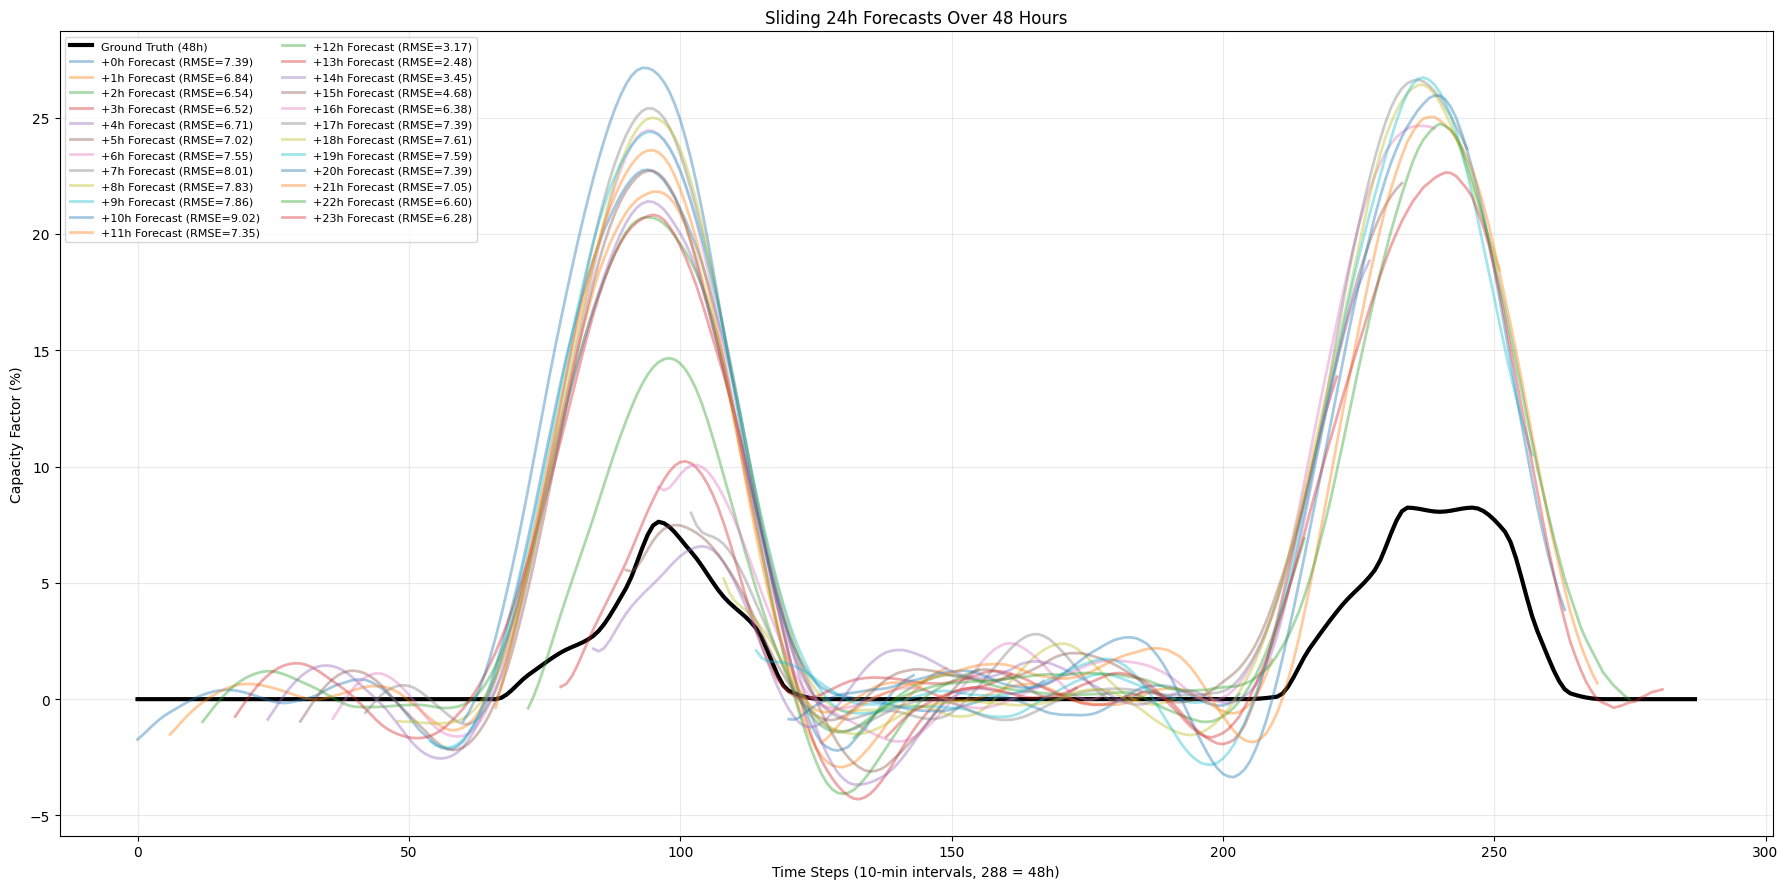

In [37]:
sliding_48h_forecast(
    model=model,
    df_clean=df_clean,
    hist_feats=hist_feats,
    fcst_feats=fcst_feats,
    scaler_target=st,
    config=config,
    start_idx=0      # choose ANY valid point
)


In [47]:
def sliding_48h_forecast_with_individual_plots(
    model,
    df_clean,
    hist_feats,
    fcst_feats,
    config,
    start_idx=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_squared_error
    import torch

    hist_steps = config["past_hours"] * 6
    fut_steps  = config["future_hours"] * 6

    # ---------------------------------------------------------
    # 🔍 1) Auto-detect the target column (capacity factor)
    # ---------------------------------------------------------
    target_candidates = [
        c for c in df_clean.columns
        if "cap" in c.lower() or "pv" in c.lower() or c.lower() in ["y", "target"]
    ]

    if len(target_candidates) == 0:
        raise ValueError(f"No target column found in df_clean. Columns: {df_clean.columns.tolist()}")

    target_col = target_candidates[0]
    print(f"[INFO] Using target column: {target_col}")

    # Full 48h ground truth
    y_full_48h = df_clean[target_col].iloc[start_idx : start_idx + 288].values

    # ---------------------------------------------------------
    # 2) Sliding predictions over 24 windows
    # ---------------------------------------------------------
    preds_24 = []

    for h in range(24):
        idx = start_idx + h * 6

        # Extract appropriate windows
        X_h = df_clean[hist_feats].iloc[idx - hist_steps: idx].values
        X_f = df_clean[fcst_feats].iloc[idx: idx + fut_steps].values

        X_h = X_h.reshape(1, hist_steps, -1)
        X_f = X_f.reshape(1, fut_steps, -1)

        X_h_tensor = torch.tensor(X_h, dtype=torch.float32)
        X_f_tensor = torch.tensor(X_f, dtype=torch.float32)

        with torch.no_grad():
            pred = model(X_h_tensor, X_f_tensor).numpy().reshape(-1)

        pred = np.clip(pred, 0, None)
        preds_24.append(pred)

    # ---------------------------------------------------------
    # 3) Combined 48h Plot
    # ---------------------------------------------------------
    plt.figure(figsize=(18, 8))

    # Ground truth (48h)
    plt.step(np.arange(288), y_full_48h, where="post", color="black", linewidth=2.5, label="Ground Truth (48h)")

    # Sliding forecasts
    for h in range(24):
        offset = h * 6
        pred = preds_24[h]

        gt_segment = y_full_48h[offset: offset + 144]

        rmse = np.sqrt(mean_squared_error(gt_segment, pred))

        plt.step(
            np.arange(offset, offset + 144),
            pred,
            where="post",
            linewidth=1.5,
            label=f"+{h}h Forecast (RMSE={rmse:.2f})"
        )

    plt.title("Sliding 24h Forecasts Over 48h")
    plt.xlabel("Time Steps (10-min intervals, 288 = 48h)")
    plt.ylabel("Capacity Factor (0–1)")
    plt.legend(ncol=3, fontsize=9)
    plt.grid(alpha=0.3)
    plt.show()

    # ---------------------------------------------------------
    # 4) Individual 24 plots
    # ---------------------------------------------------------
    for h in range(24):
        plt.figure(figsize=(8, 4))

        offset = h * 6
        pred = preds_24[h]
        gt_segment = y_full_48h[offset: offset + 144]
        rmse = np.sqrt(mean_squared_error(gt_segment, pred))

        plt.step(range(144), gt_segment, where="post", label="Ground Truth", linewidth=2)
        plt.step(range(144), pred, where="post", label=f"Prediction +{h}h (RMSE={rmse:.2f})", linewidth=2)

        plt.title(f"Sliding Forecast Starting at +{h} Hours")
        plt.xlabel("Time Steps (10-min intervals)")
        plt.ylabel("Capacity Factor (0–1)")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


[INFO] Using target column: Capacity Factor


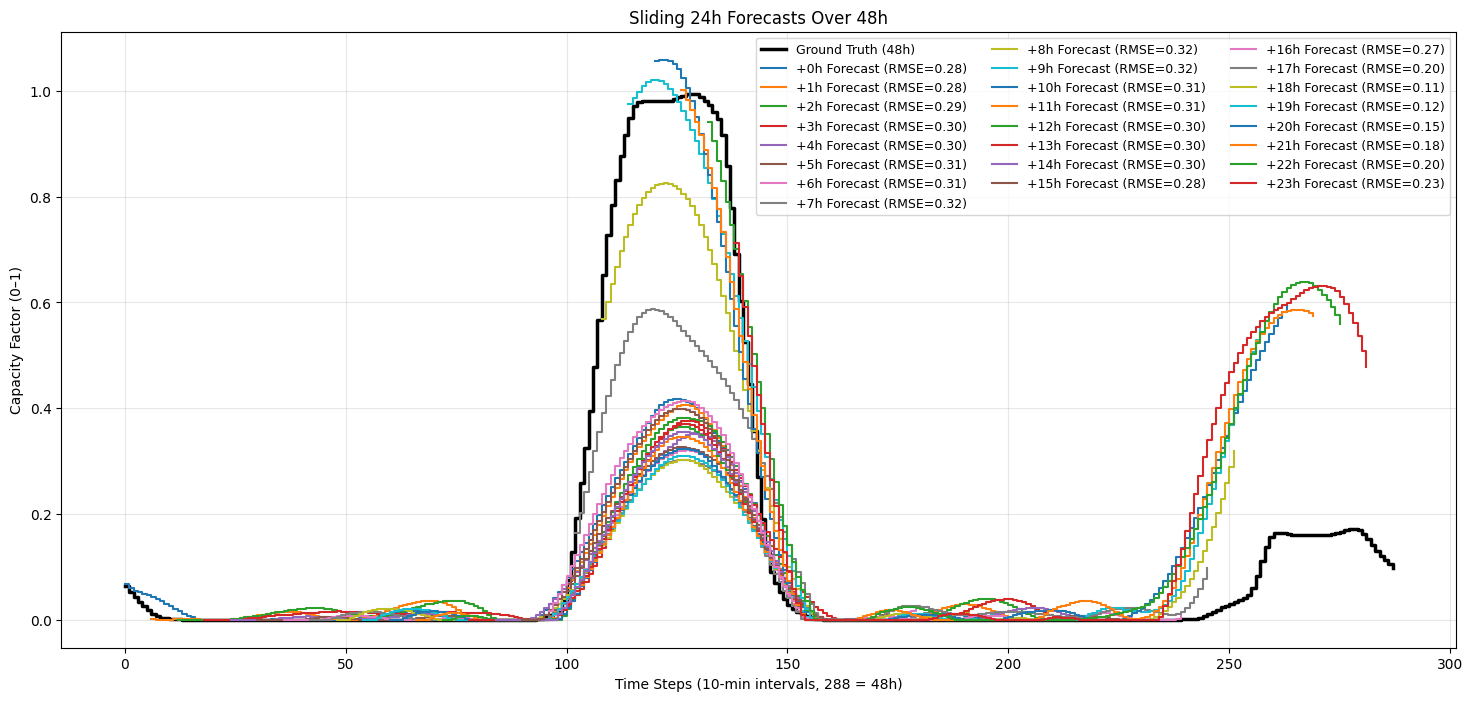

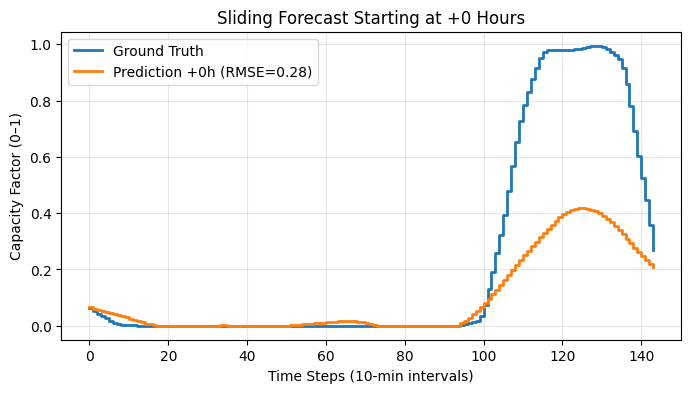

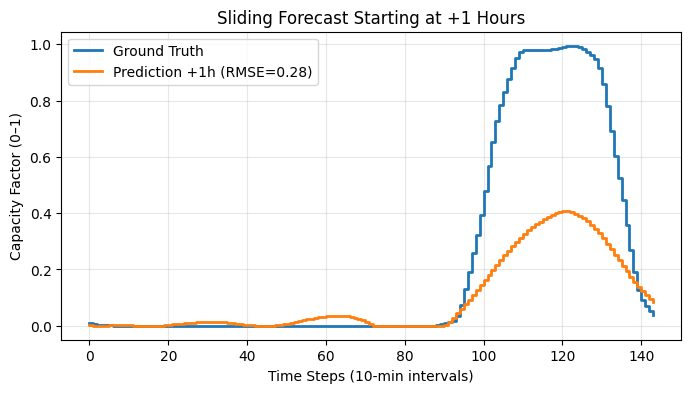

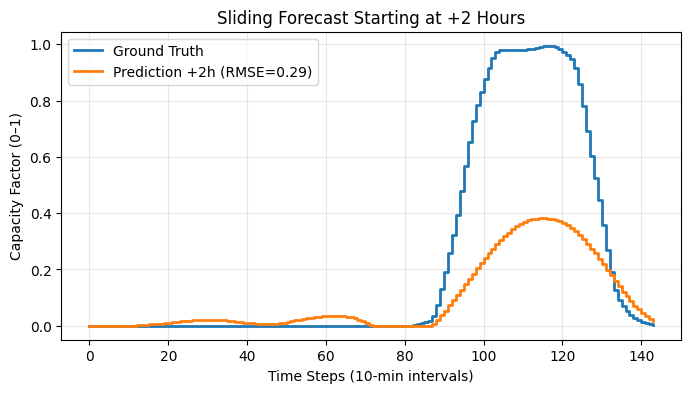

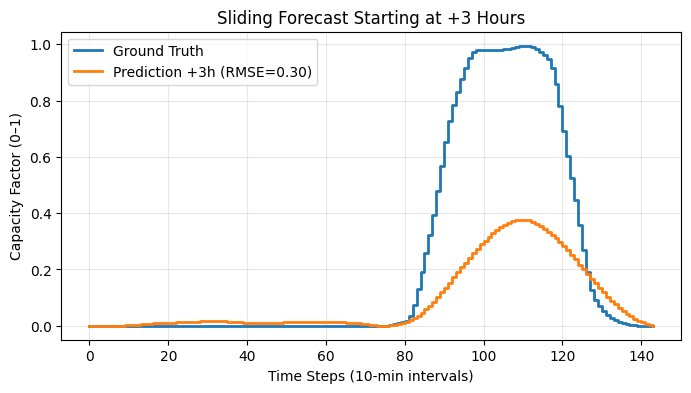

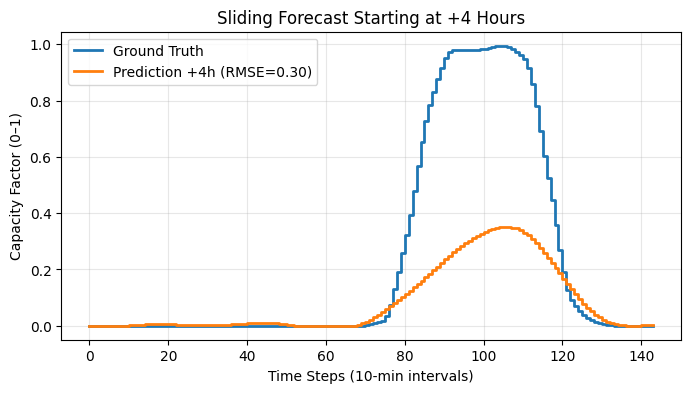

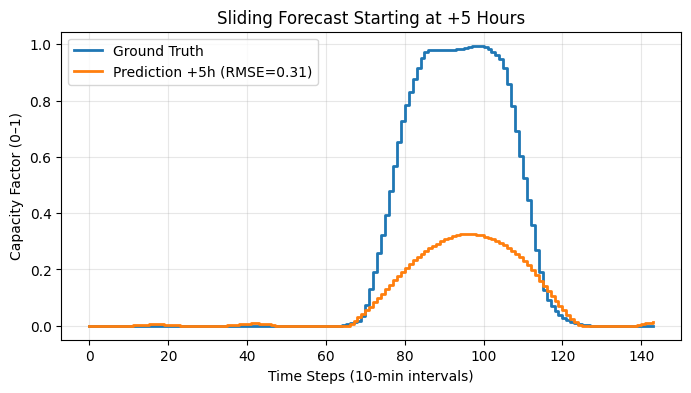

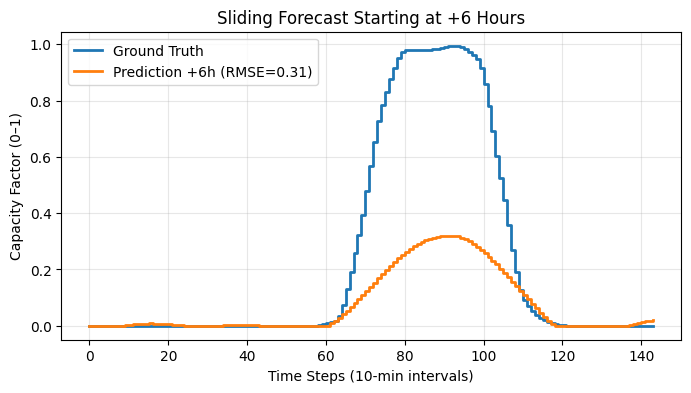

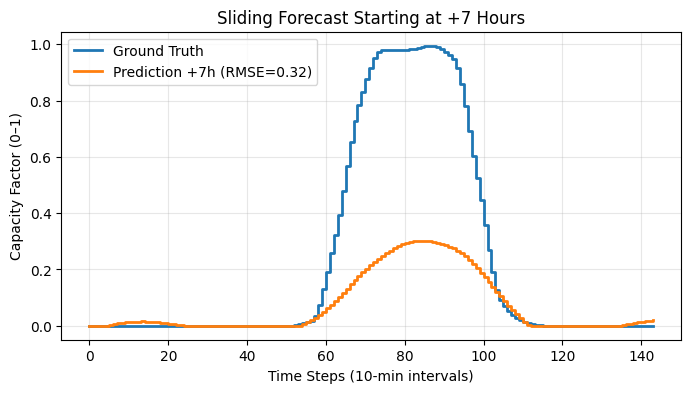

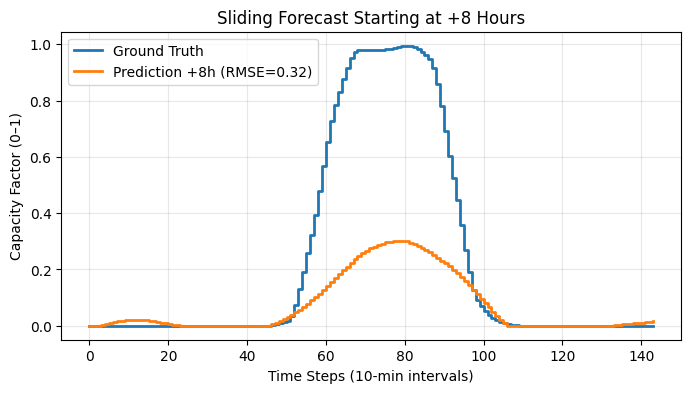

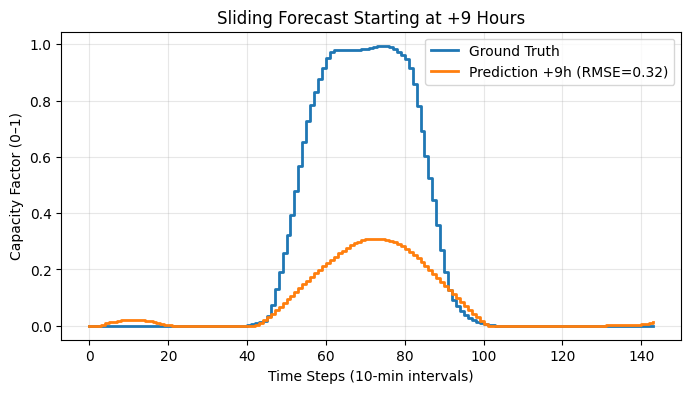

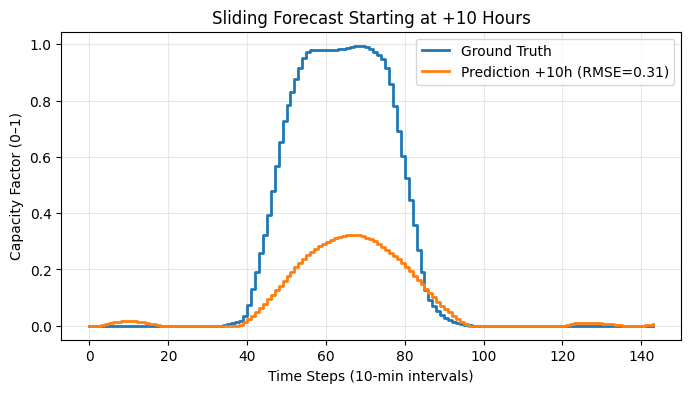

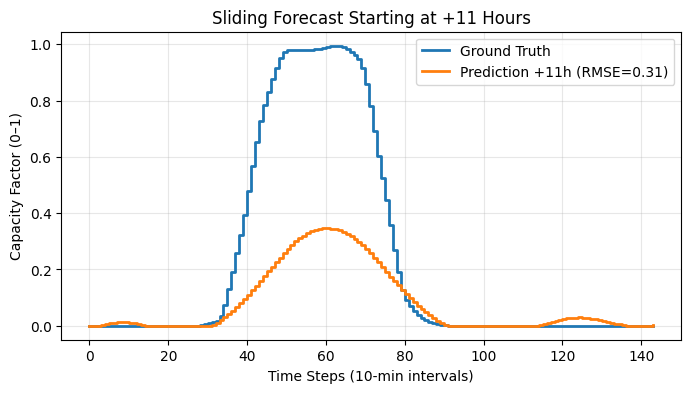

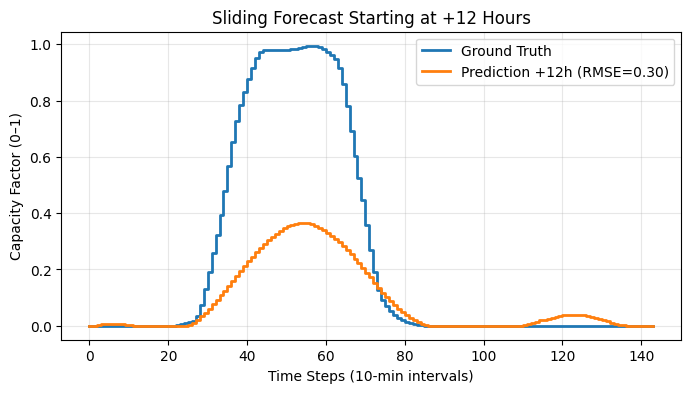

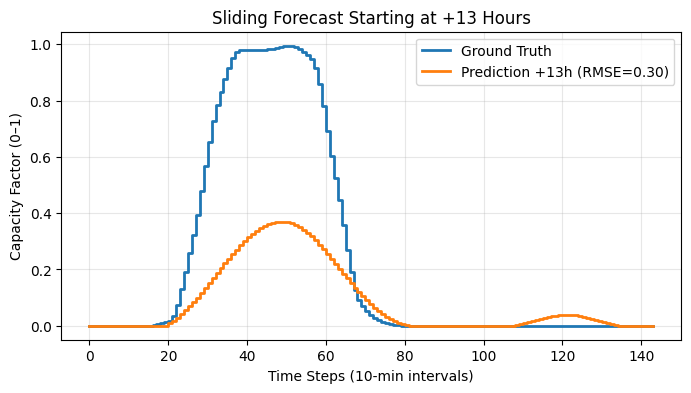

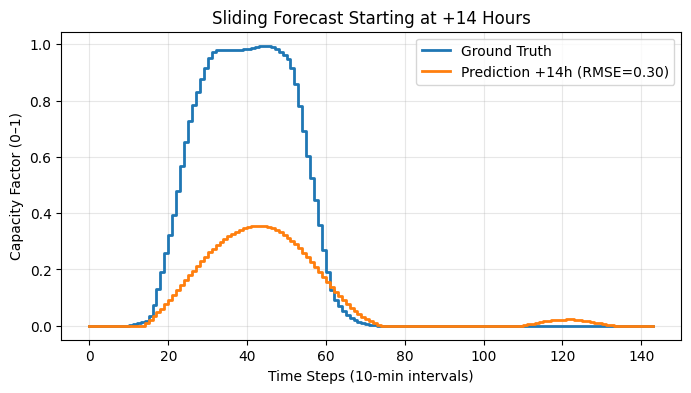

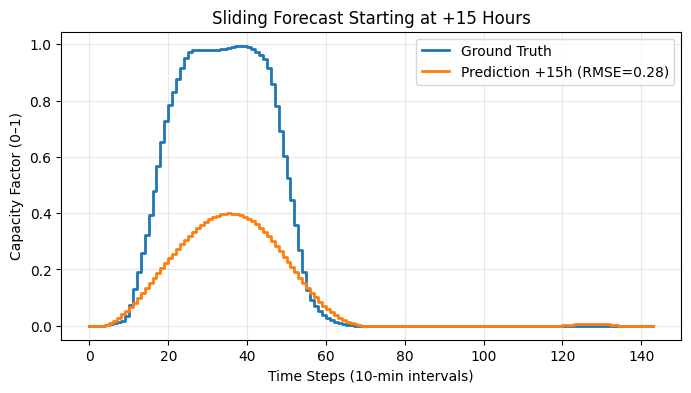

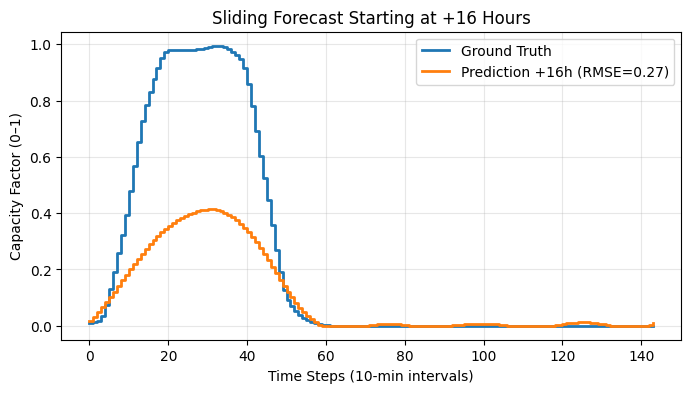

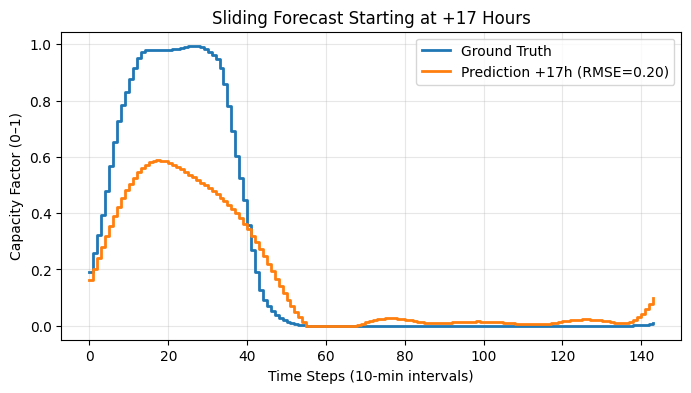

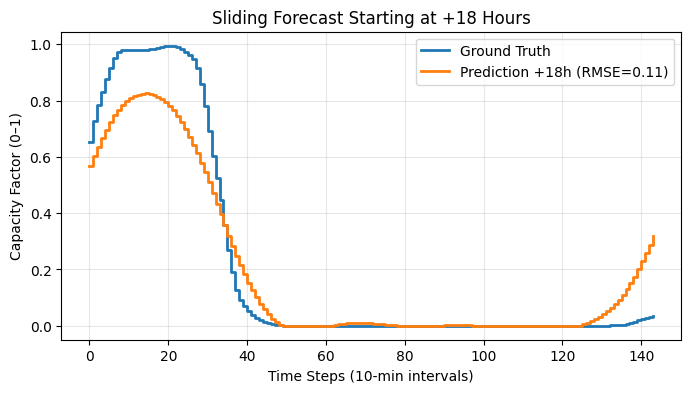

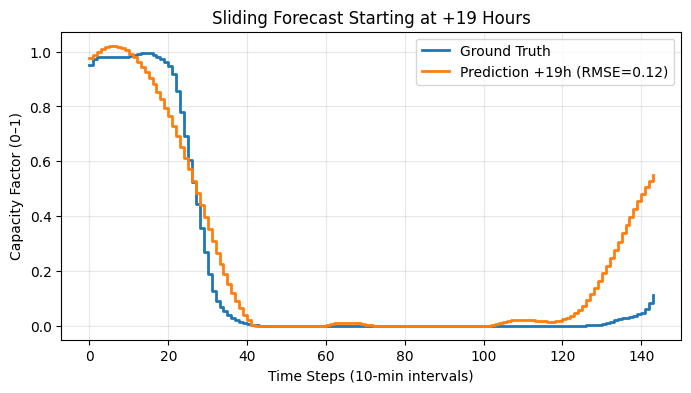

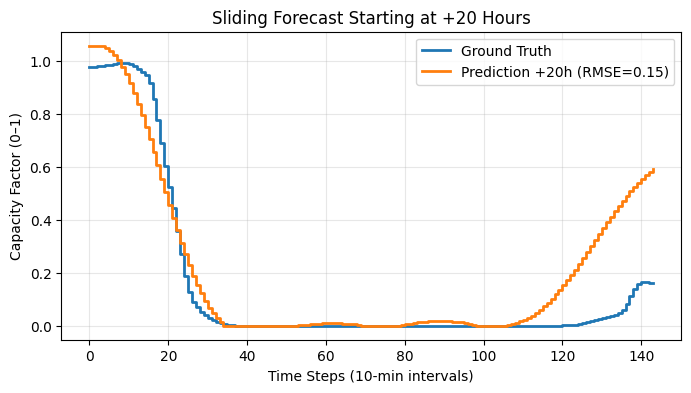

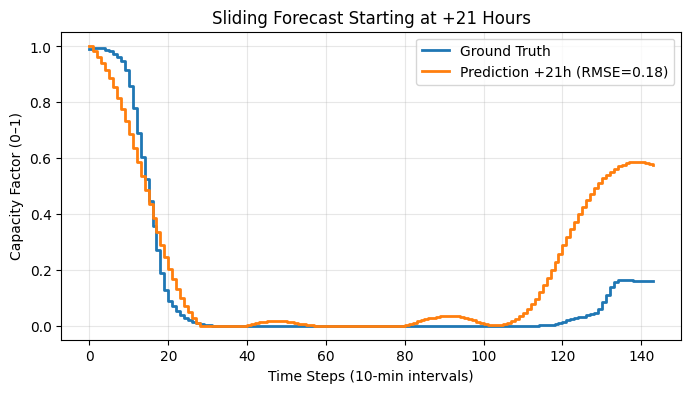

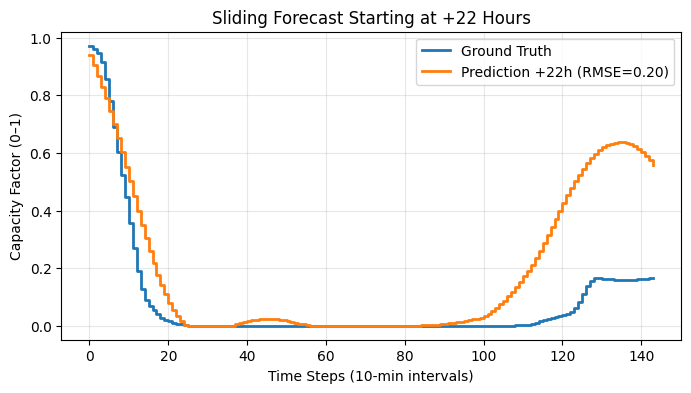

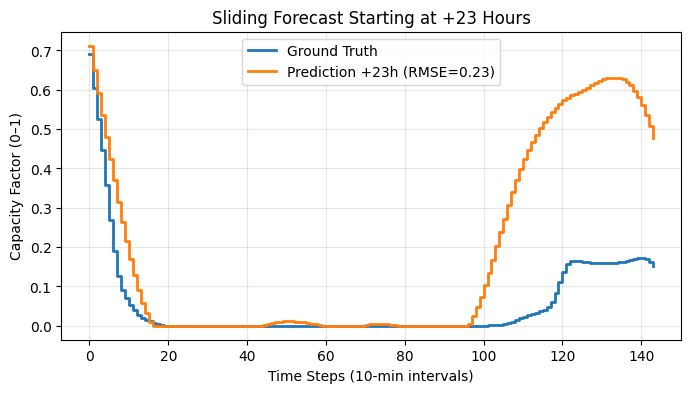

In [48]:
sliding_48h_forecast_with_individual_plots(
    model,
    df_clean,
    hist_feats,
    fcst_feats,
    config,
    start_idx=400
)